In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print(df.shape)
df.head()

Saving country_wise_latest-selected-columns.csv to country_wise_latest-selected-columns.csv
(187, 10)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34
3,Andorra,907,52,803,52,10,0,0,5.73,88.53
4,Angola,950,41,242,667,18,1,0,4.32,25.47


In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.info()

['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country/Region         187 non-null    object 
 1   Confirmed              187 non-null    int64  
 2   Deaths                 187 non-null    int64  
 3   Recovered              187 non-null    int64  
 4   Active                 187 non-null    int64  
 5   New cases              187 non-null    int64  
 6   New deaths             187 non-null    int64  
 7   New recovered          187 non-null    int64  
 8   Deaths / 100 Cases     187 non-null    float64
 9   Recovered / 100 Cases  187 non-null    float64
dtypes: float64(2), int64(7), object(1)
memory usage: 14.7+ KB


In [ ]:
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Country/Region           0
Confirmed                0
Deaths                   0
Recovered                0
Active                   0
New cases                0
New deaths               0
New recovered            0
Deaths / 100 Cases       0
Recovered / 100 Cases    0
dtype: int64
Duplicate Rows: 0


In [ ]:
date_cols = [c for c in df.columns if "date" in c.lower()]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]], errors="coerce")
print(df.describe())

          Confirmed         Deaths     Recovered        Active     New cases  \
count  1.870000e+02     187.000000  1.870000e+02  1.870000e+02    187.000000   
mean   8.813094e+04    3497.518717  5.063148e+04  3.400194e+04   1222.957219   
std    3.833187e+05   14100.002482  1.901882e+05  2.133262e+05   5710.374790   
min    1.000000e+01       0.000000  0.000000e+00  0.000000e+00      0.000000   
25%    1.114000e+03      18.500000  6.265000e+02  1.415000e+02      4.000000   
50%    5.059000e+03     108.000000  2.815000e+03  1.600000e+03     49.000000   
75%    4.046050e+04     734.000000  2.260600e+04  9.149000e+03    419.500000   
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06  56336.000000   

        New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  
count   187.000000     187.000000          187.000000             187.000000  
mean     28.957219     933.812834            3.019519              64.820535  
std     120.037173    4197.719635         

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical Columns:", num_cols)

Numerical Columns: ['Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases']


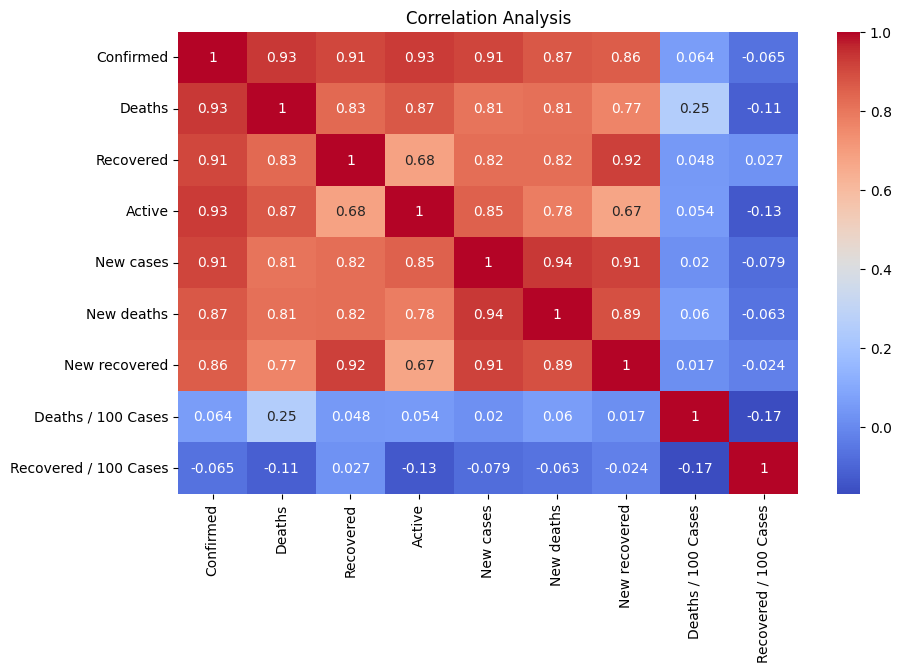

In [ ]:
if len(num_cols) >= 2:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Analysis")
    plt.show()

In [ ]:
if date_cols and num_cols:
    date_col = date_cols[0]
    value_col = num_cols[0]
    trend = df.groupby(date_col)[value_col].sum()

    plt.figure(figsize=(12,5))
    plt.plot(trend)
    plt.title("COVID-19 Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel(value_col)
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
if len(num_cols) >= 2:
    x = df[num_cols[0]].dropna()
    y = df.loc[x.index, num_cols[1]].dropna()
    x, y = x.align(y, join="inner")

    correlation, p_value = pearsonr(x, y)
    print("Correlation:", correlation)
    print("P-value:", p_value)

Correlation: 0.9346984343393535
P-value: 4.8856399457711744e-85


In [ ]:
data = df[num_cols].dropna()
X = data[[num_cols[0]]]
y = data[num_cols[1]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3277.4754375596644
RMSE: 7901.046835773879
R2 Score: 0.27192084936935956


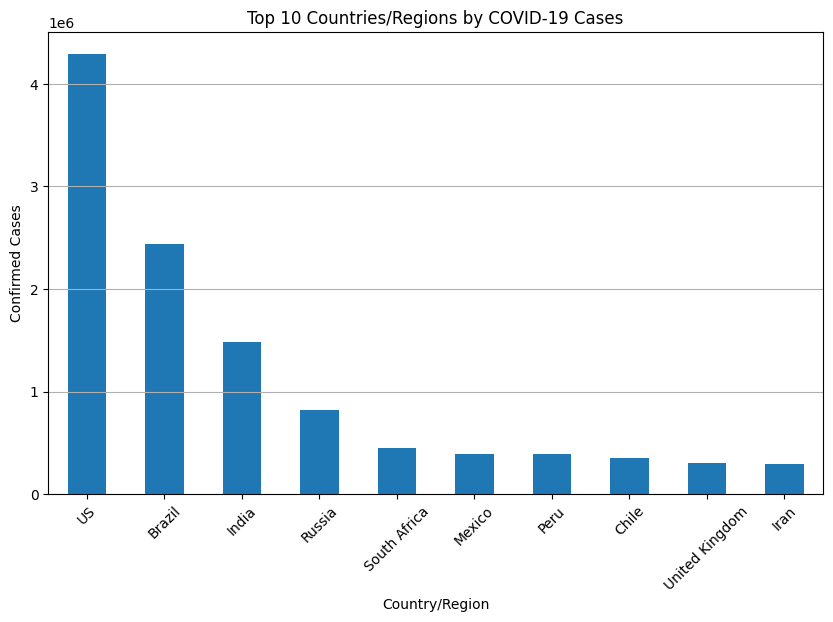

In [ ]:
loc_col = next((c for c in df.columns if any(x in c.lower() for x in ["country", "region", "location"])), None)
case_col = next((c for c in df.columns if "confirm" in c.lower() or "case" in c.lower()), None)

if loc_col and case_col:
    top = df.groupby(loc_col)[case_col].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(10,6))
    top.plot(kind="bar")
    plt.title("Top 10 Countries/Regions by COVID-19 Cases")
    plt.xlabel(loc_col)
    plt.ylabel("Confirmed Cases")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

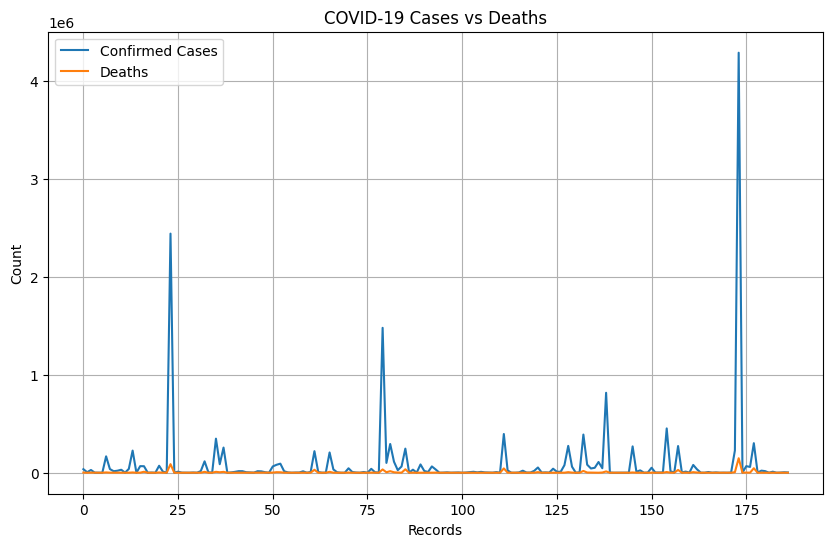

In [ ]:
case_col = next((c for c in df.columns if "confirm" in c.lower() or "case" in c.lower()), None)
death_col = next((c for c in df.columns if "death" in c.lower()), None)

if case_col and death_col:
    plt.figure(figsize=(10,6))
    plt.plot(df[case_col].values, label="Confirmed Cases")
    plt.plot(df[death_col].values, label="Deaths")
    plt.title("COVID-19 Cases vs Deaths")
    plt.xlabel("Records")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True)
    plt.show()

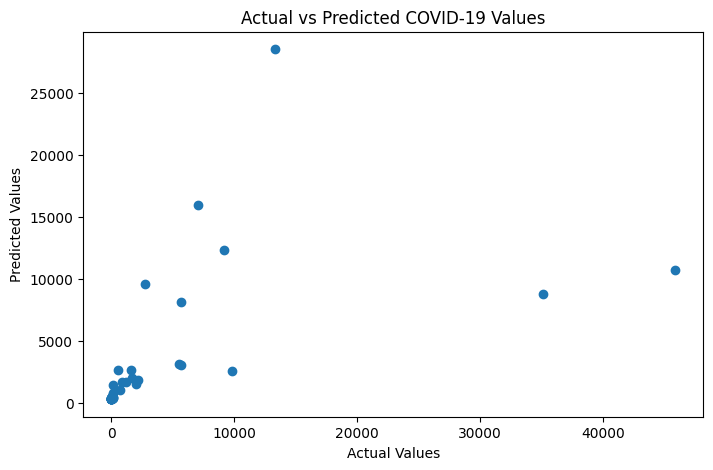

KEY INSIGHTS
1. COVID-19 trends can be analyzed over time.
2. Correlation analysis identifies relationships between numerical variables.
3. Linear Regression can be used for basic prediction.
4. MAE, RMSE and R2 Score evaluate model performance.
5. Analytics can support healthcare resource planning and decision-making.


In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted COVID-19 Values")
plt.show()

print("KEY INSIGHTS")
print("1. COVID-19 trends can be analyzed over time.")
print("2. Correlation analysis identifies relationships between numerical variables.")
print("3. Linear Regression can be used for basic prediction.")
print("4. MAE, RMSE and R2 Score evaluate model performance.")
print("5. Analytics can support healthcare resource planning and decision-making.")